In [ ]:
# Liberias fundamentales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética básica para los gráficos
sns.set_style('whitegrid')

# Cargar el dataset
df_california = pd.read_csv('housing.csv')

# 1. Mostrar las primeras 5 filas para entender la estructura visualmente
print("--- Primeras filas del dataset ---")
display(df_california.head())

# 2. Información básica: tipos de datos y conteo de valores no nulos
print("\n--- Información del Dataset ---")
df_california.info()

# 3. Estadísticas descriptivas: media, desviación estándar, mínimos y máximos
print("\n--- Estadísticas Descriptivas Básicas---")
display(df_california.describe())

--- Primeras filas del dataset ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB

--- Estadísticas Descriptivas Básicas---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# Limpieza y preprocesamiento base

In [5]:
# 1. Manejo de valores nulos: Identificar y contar los valores nulos en cada columna
print("\n--- Conteo de Valores Nulos por Columna ---")
print(df_california.isnull().sum())


--- Conteo de Valores Nulos por Columna ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [13]:
# 1. Manejo de valores nulos
# Calculamos la mediana de los dormitorios
mediana_dormitorios = df_california['total_bedrooms'].median()

# Rellenamos (imputamos) los valores nulos con esa mediana
df_california.fillna({'total_bedrooms': mediana_dormitorios}, inplace=True)

# Verificamos que ya no haya nulos
print("Valores nulos después de la limpieza:")
print(df_california.isnull().sum())

# 2. Análisis de la variable categórica (texto)
print("\n--- Categorías en 'ocean_proximity' ---")
display(df_california['ocean_proximity'].value_counts())

Valores nulos después de la limpieza:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

--- Categorías en 'ocean_proximity' ---


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

# Análisis Exploratorio Inicial (Distribuciones individuales)

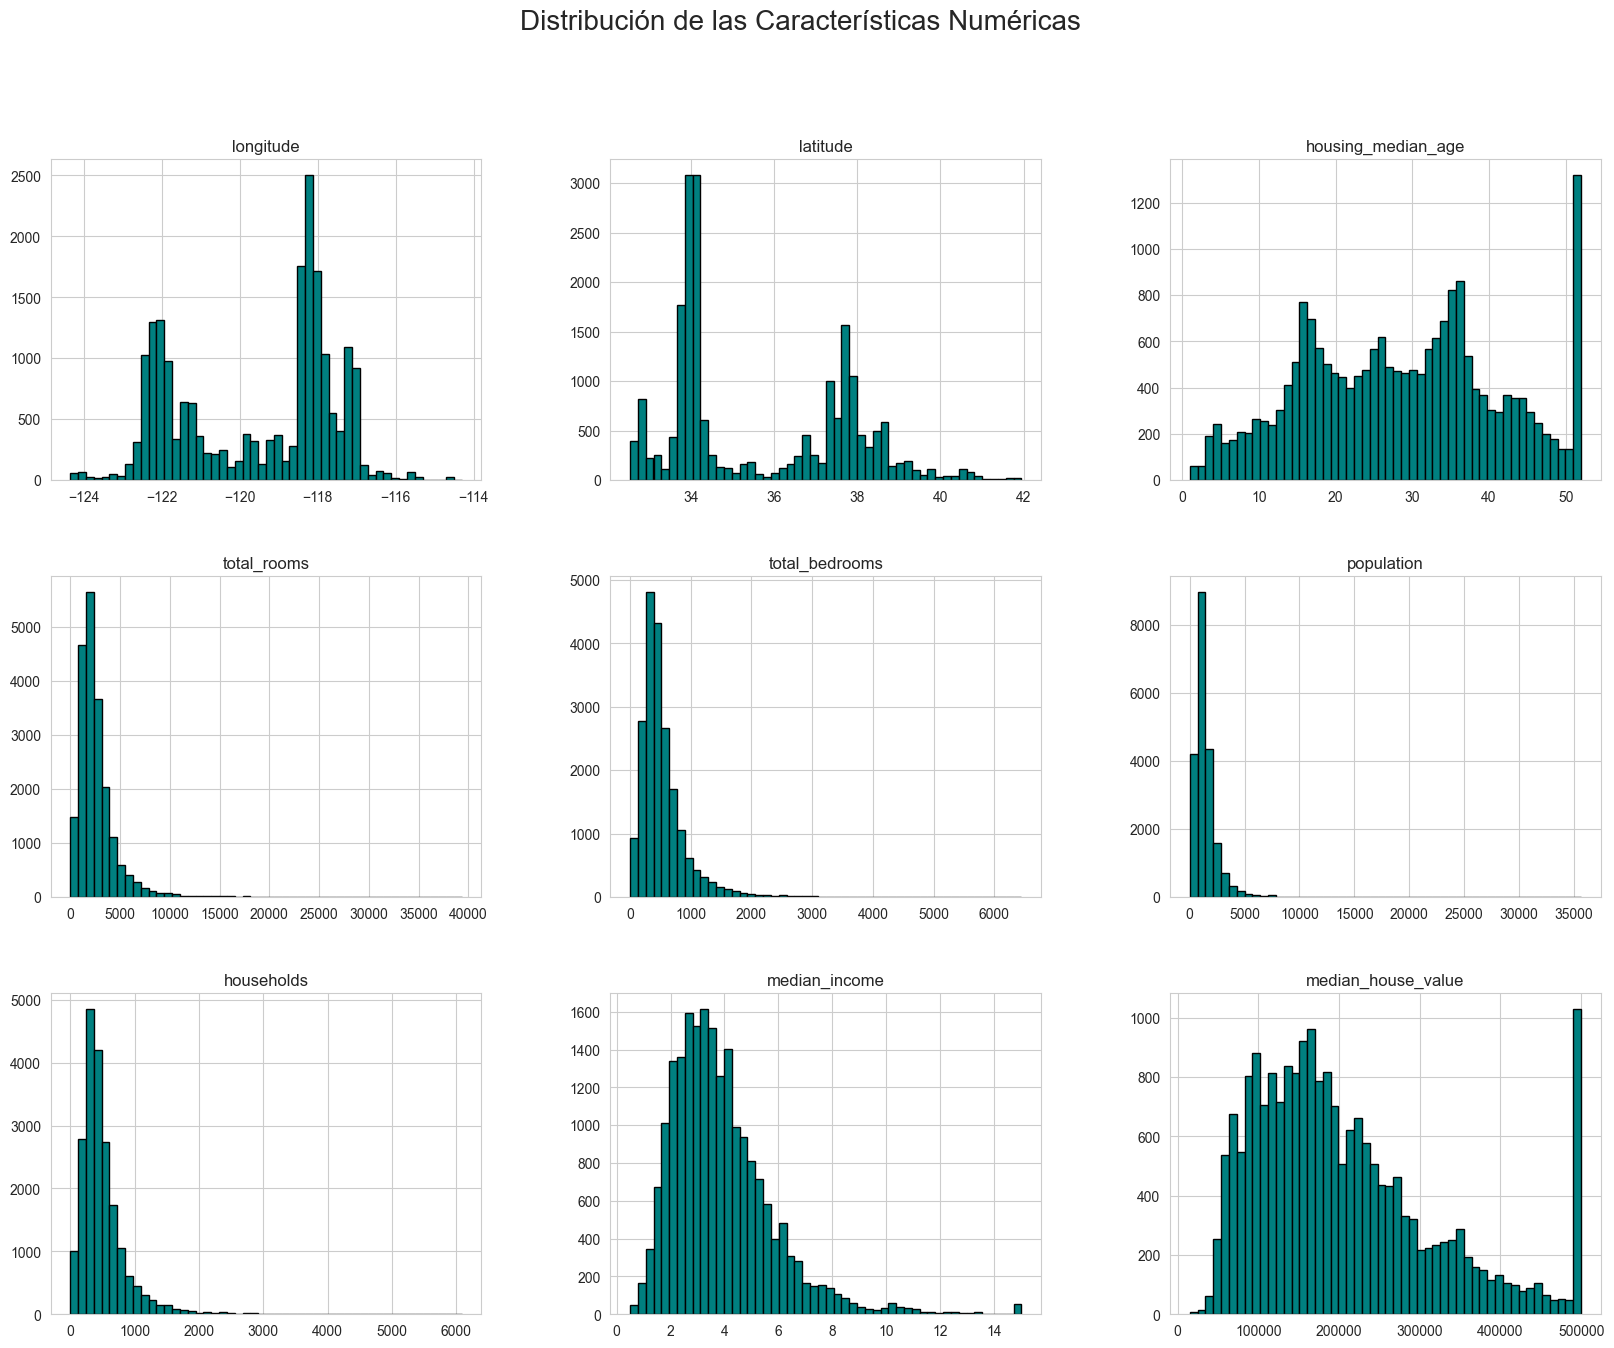

In [25]:
# Mapear la distribución de todas las variables numéricas
# bins=50 define la cantidad de "barras" o cajones en los gráficos
# figsize ajusta el tamaño total de la imagen para que sea vea bien en la pantalla
df_california.hist(bins=50, figsize=(20,15), color='teal', edgecolor='black')

# Añade un título general
plt.suptitle("Distribución de las Características Numéricas", fontsize=20)

# Mostrar los gráficos
plt.show()

### Conclusiones del Análisis de Distribuciones

Al observar los histogramas de las variables numéricas, podemos identificar tres fenómenos clave en los datos que debemos tener en cuenta para futuros modelos:

1. **Topes Artificiales (Capping):** La variable `median_house_value` muestra un pico atípico y masivo al final de su distribución (alrededor de los $500,000). Esto indica que los datos fueron limitados artificialmente durante su recolección; cualquier valor superior a ese umbral fue registrado con ese valor máximo. Ocurre un fenómeno idéntico en `housing_median_age` alrededor de los 50 años.
2. **Sesgo Positivo (Right-Skewness):** Variables como `median_income`, `total_rooms` y `population` tienen una "cola pesada" que se extiende hacia la derecha. Esto significa que la mayoría de los vecindarios tienen valores bajos o medios, pero existen unos pocos vecindarios con valores extremadamente altos (outliers) que estiran la distribución. 
3. **Escalas Diferentes:** Las variables están medidas en escalas muy distintas (ej. ingresos en decenas de miles vs. población en miles de personas). Si aplicamos algoritmos de Machine Learning más adelante, será crucial estandarizar o escalar estos datos.

# EDA AVANZADO (Segmentación y Filtrado)

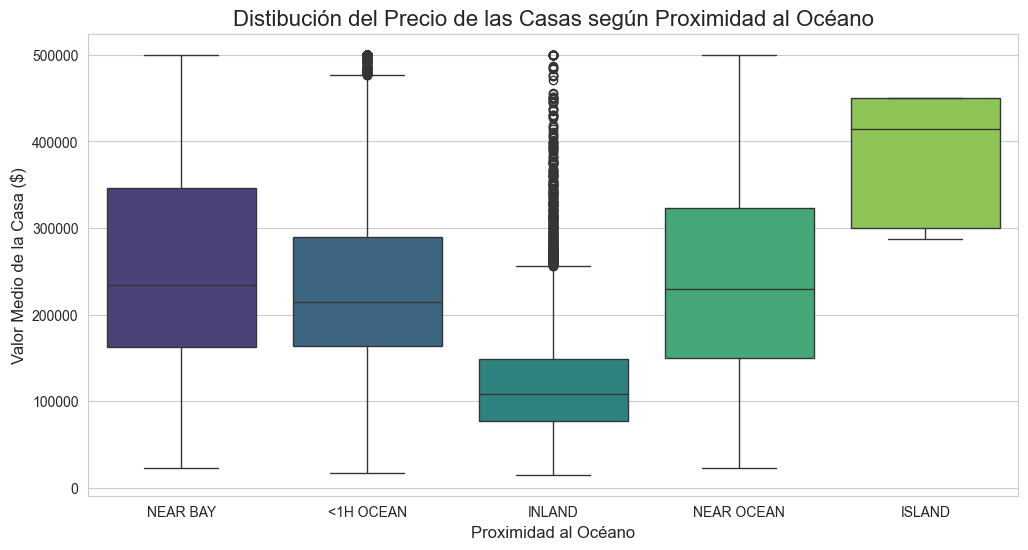

In [37]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Creación del boxplot
# x: nuestra categoría de texto, y: el precio que queremos analizar
sns.boxplot(
    data=df_california,
    x='ocean_proximity',
    y='median_house_value',
    hue='ocean_proximity', # Asignamos colores por categoría
    palette='viridis',
    legend=False
)

# Títulos y etiquetas para entender sin contexto
plt.title('Distibución del Precio de las Casas según Proximidad al Océano', fontsize=16)
plt.xlabel('Proximidad al Océano', fontsize=12)
plt.ylabel('Valor Medio de la Casa ($)', fontsize=12)

# Mostrar el gráfico
plt.show()